In [39]:
import pandas as pd; df = pd.read_csv("../data/diabetes_data/diabetic_data.csv")

In [40]:
import numpy as np

df = df.replace('?', np.nan)


In [41]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

In [42]:
df = df.drop(columns=['weight', 'payer_code', 'medical_specialty'])
df['race'] = df['race'].fillna('Unknown')

In [43]:
print(df['patient_nbr'].duplicated().sum())   # how many extra rows this affects

df = df.sort_values('encounter_id')
df = df.drop_duplicates(subset='patient_nbr', keep='first')
df.shape

30248


(71518, 47)

In [44]:
exclude_ids = [11, 13, 14, 19, 20, 21]
df = df[~df['discharge_disposition_id'].isin(exclude_ids)]
df.shape

(69973, 47)

In [45]:
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)
df['readmitted_binary'].value_counts()

readmitted_binary
0    63696
1     6277
Name: count, dtype: int64

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

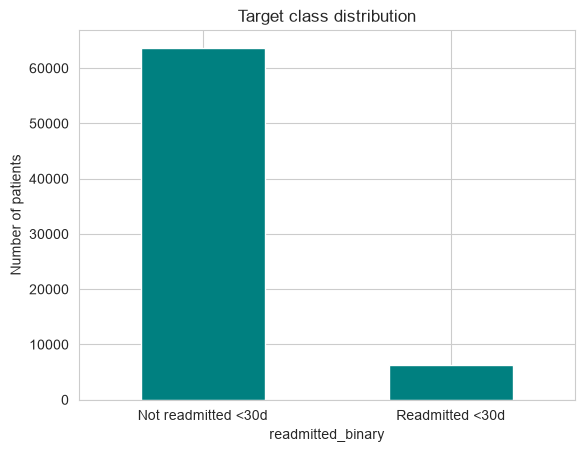

In [47]:
df['readmitted_binary'].value_counts().plot(kind='bar', color='teal')
plt.xticks([0, 1], ['Not readmitted <30d', 'Readmitted <30d'], rotation=0)
plt.ylabel('Number of patients')
plt.title('Target class distribution')
plt.show()

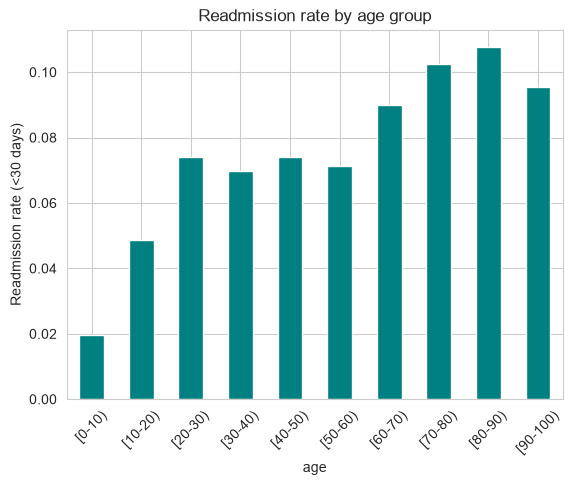

In [48]:
age_rate = df.groupby('age')['readmitted_binary'].mean().sort_index()
age_rate.plot(kind='bar', color='teal')
plt.ylabel('Readmission rate (<30 days)')
plt.title('Readmission rate by age group')
plt.xticks(rotation=45)
plt.show()

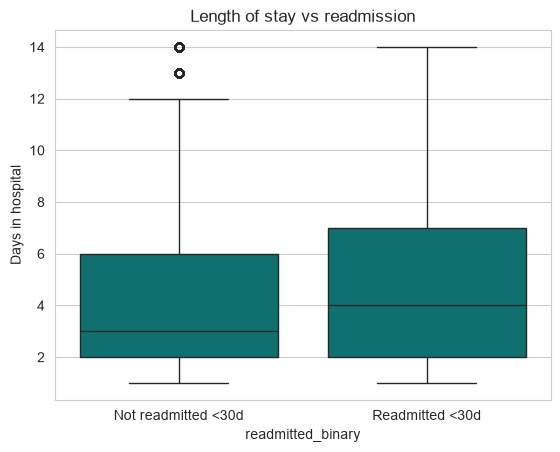

In [49]:
sns.boxplot(data=df, x='readmitted_binary', y='time_in_hospital', color='teal')
plt.xticks([0, 1], ['Not readmitted <30d', 'Readmitted <30d'])
plt.ylabel('Days in hospital')
plt.title('Length of stay vs readmission')
plt.show()

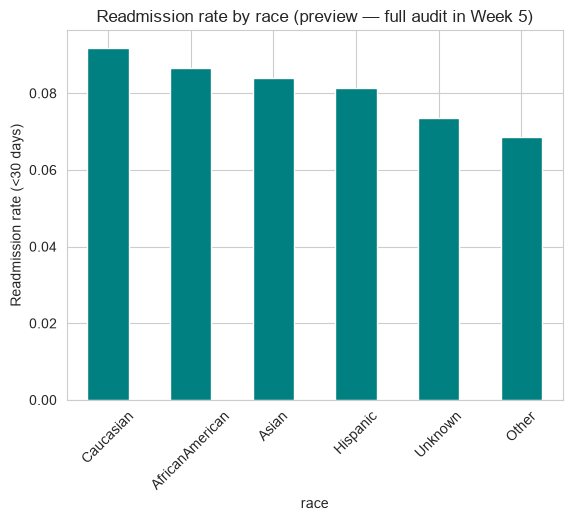

In [50]:
race_rate = df.groupby('race')['readmitted_binary'].mean().sort_values(ascending=False)
race_rate.plot(kind='bar', color='teal')
plt.ylabel('Readmission rate (<30 days)')
plt.title('Readmission rate by race (preview — full audit in Week 5)')
plt.xticks(rotation=45)
plt.show()